# Physical Reservoir Simulation for stock time series (software model)
This notebook simulates a simple physical-like reservoir (nonlinear dynamical system with delay),
trains a linear readout, evaluates, and saves the model. This is a software simulation of a physical reservoir.

Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from data_utils import load_close_matrix, train_val_test_split, windowed_dataset
from logger import get_logger

MODELS_DIR = os.path.join(os.getcwd(), "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# Initialize logger
logger = get_logger("physical_reservoir")

1) Load data

In [2]:
df = load_close_matrix()
if df.empty:
    logger.error("No ticker CSVs found in ./tickers. Run ticker.py first.")
    raise RuntimeError("No ticker CSVs found in ./tickers. Run ticker.py first.")
series = df.iloc[:, 0].astype(float).dropna()
logger.info(f"Using ticker: {series.name}, length: {len(series)}")
print("Using ticker:", series.name, "length:", len(series))

2026-03-07 23:48:29,133 - data_utils - INFO - Found 10 ticker CSV files
2026-03-07 23:48:29,136 - data_utils - INFO - Loading data from 10 files...
2026-03-07 23:48:29,287 - data_utils - INFO - Created merged matrix with shape (255, 10)
2026-03-07 23:48:29,290 - physical_reservoir - INFO - Using ticker: ARLO, length: 255


Using ticker: ARLO length: 255


2) Physical reservoir simulation (nonlinear delay reservoir)

In [3]:
class DelayReservoir:
    def __init__(self, n_neurons=1000, input_gain=0.5, feedback=0.9, nonlin=np.tanh, random_state=42):
        self.logger = get_logger("physical_reservoir")
        self.n_neurons = n_neurons  # virtual nodes
        self.input_gain = input_gain
        self.feedback = feedback
        self.nonlin = nonlin
        self.rs = np.random.Generator(np.random.PCG64(random_state))
        # mask to map input to virtual nodes
        self.mask = (self.rs.random(self.n_neurons) - 0.5) * 2.0
        self.state = np.zeros(self.n_neurons)
        self.logger.debug(f"Initialized DelayReservoir with n_neurons={n_neurons}, input_gain={input_gain}, feedback={feedback}")

    def run(self, inputs):
        # inputs: (T, 1)
        T = inputs.shape[0]
        self.logger.debug(f"Running DelayReservoir for {T} timesteps")
        states = np.zeros((T, self.n_neurons))
        for t in range(T):
            u = inputs[t, 0]
            # single scalar node update with virtual node mask
            x = self.nonlin(self.feedback * self.state + self.input_gain * self.mask * u)
            self.state = x
            states[t] = self.state
        self.logger.debug(f"DelayReservoir run completed, states shape: {states.shape}")
        return states

3) Prepare windows and normalize

In [4]:
train, val, test = train_val_test_split(series, train_frac=0.7, val_frac=0.15)
window_size = 10
logger.info(f"Data split - Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
logger.info(f"Using window size: {window_size}")
X_train, y_train = windowed_dataset(train, window_size)
X_val, y_val = windowed_dataset(np.concatenate([train[-window_size:], val]), window_size)
X_test, y_test = windowed_dataset(np.concatenate([val[-window_size:], test]), window_size)

mu = X_train.mean()
sigma = X_train.std() + 1e-9
X_train_n = (X_train - mu) / sigma
X_val_n = (X_val - mu) / sigma
X_test_n = (X_test - mu) / sigma
logger.debug(f"Data normalized - mu: {mu:.6f}, sigma: {sigma:.6f}")

2026-03-07 23:48:29,328 - physical_reservoir - INFO - Data split - Train: 178, Val: 38, Test: 39
2026-03-07 23:48:29,330 - physical_reservoir - INFO - Using window size: 10


4) Run delay reservoir and train readout

In [5]:
dr = DelayReservoir(n_neurons=300, input_gain=0.6, feedback=0.95)
logger.info("Created DelayReservoir with 300 virtual nodes")
def windows_to_inputs(X):
    return X.reshape(X.shape[0], X.shape[1], 1)

def delay_states_for_windows(dr, x_n):
    feats = []
    for w in x_n:
        seq = w.reshape(len(w), 1)
        states = dr.run(seq)
        feats.append(states[-1])  # last virtual node states
    return np.vstack(feats)

R_train = delay_states_for_windows(dr, X_train_n)
R_val = delay_states_for_windows(dr, X_val_n)
R_test = delay_states_for_windows(dr, X_test_n)

ridge = Ridge(alpha=1.0, random_state=42)
logger.info("Training ridge regression readout...")
ridge.fit(R_train, y_train)
y_pred = ridge.predict(R_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 1) Baseline Comparison - Naive Last-Value
naive_pred = y_test[:-1]
naive_mse = mean_squared_error(y_test[1:], naive_pred)
naive_mae = mean_absolute_error(y_test[1:], naive_pred)
improvement_mse = ((naive_mse - mse) / naive_mse) * 100
improvement_mae = ((naive_mae - mae) / naive_mae) * 100

# 2) Directional Accuracy
y_true_direction = (y_test[1:] > y_test[:-1]).astype(int)
y_pred_direction = (y_pred[1:] > y_pred[:-1]).astype(int)
directional_acc = accuracy_score(y_true_direction, y_pred_direction) * 100

# Log all metrics
logger.info(f"Physical Reservoir Test MSE: {mse:.6f}, MAE: {mae:.6f}")
logger.info(f"R-squared: {r2:.4f}")
logger.info(f"Naive Baseline MSE: {naive_mse:.6f}, MAE: {naive_mae:.6f}")
logger.info(f"Physical vs Naive Improvement: MSE {improvement_mse:.2f}%, MAE {improvement_mae:.2f}%")
logger.info(f"Directional Accuracy: {directional_acc:.2f}%")

print(f"Physical Reservoir Test MSE: {mse:.6f}, MAE: {mae:.6f}")
print(f"R-squared: {r2:.4f}")
print(f"Naive Baseline MSE: {naive_mse:.6f}, MAE: {naive_mae:.6f}")
print(f"Physical vs Naive Improvement: MSE {improvement_mse:.2f}%, MAE {improvement_mae:.2f}%")
print(f"Directional Accuracy: {directional_acc:.2f}%")

2026-03-07 23:48:29,359 - physical_reservoir - INFO - Created DelayReservoir with 300 virtual nodes
2026-03-07 23:48:29,413 - physical_reservoir - INFO - Training ridge regression readout...
2026-03-07 23:48:29,440 - physical_reservoir - INFO - Physical Reservoir Test MSE: 1.666649, MAE: 0.898446
2026-03-07 23:48:29,444 - physical_reservoir - INFO - R-squared: -0.2213
2026-03-07 23:48:29,446 - physical_reservoir - INFO - Naive Baseline MSE: 0.423868, MAE: 0.360000
2026-03-07 23:48:29,449 - physical_reservoir - INFO - Physical vs Naive Improvement: MSE -293.20%, MAE -149.57%
2026-03-07 23:48:29,452 - physical_reservoir - INFO - Directional Accuracy: 42.11%


Physical Reservoir Test MSE: 1.666649, MAE: 0.898446
R-squared: -0.2213
Naive Baseline MSE: 0.423868, MAE: 0.360000
Physical vs Naive Improvement: MSE -293.20%, MAE -149.57%
Directional Accuracy: 42.11%


5) Visualize predictions

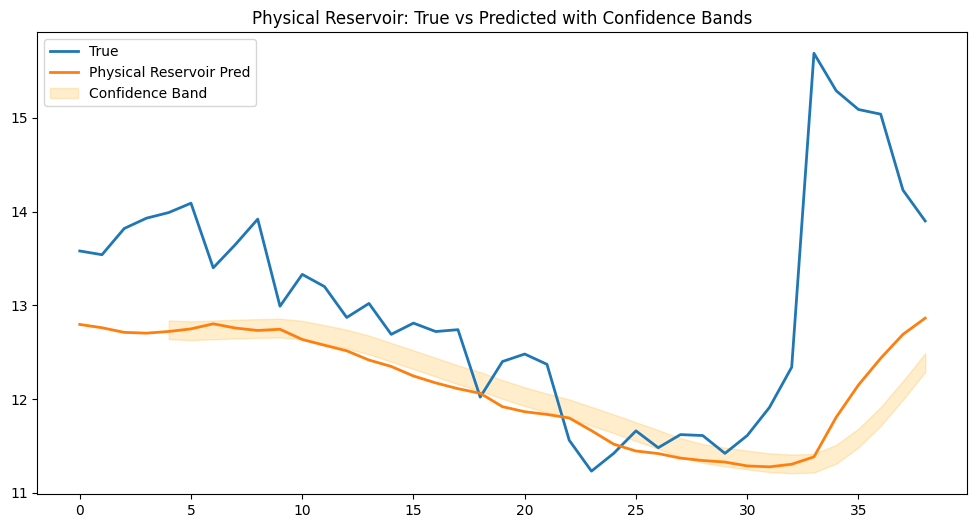

In [6]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label="True", linewidth=2)
plt.plot(y_pred, label="Physical Reservoir Pred", linewidth=2)
# Add 5-day moving average as confidence band
pred_series = pd.Series(y_pred)
ma_band = pred_series.rolling(5).mean()
plt.fill_between(range(len(y_pred)), ma_band - 0.1, ma_band + 0.1, alpha=0.2, color='orange', label='Confidence Band')
plt.legend()
plt.title("Physical Reservoir: True vs Predicted with Confidence Bands")
plt.show()

6) Residual Analysis

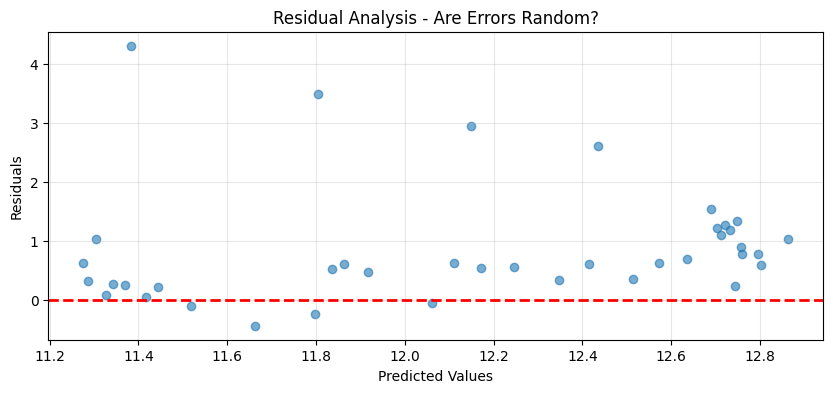

2026-03-07 23:48:30,275 - physical_reservoir - INFO - Residual Mean: 0.856959
2026-03-07 23:48:30,278 - physical_reservoir - INFO - Residual Std: 0.965542


Residual Mean: 0.856959
Residual Std: 0.965542


In [7]:
residuals = y_test - y_pred
plt.figure(figsize=(10,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis - Are Errors Random?')
plt.grid(True, alpha=0.3)
plt.show()

# Additional residual statistics
logger.info(f"Residual Mean: {np.mean(residuals):.6f}")
logger.info(f"Residual Std: {np.std(residuals):.6f}")
print(f"Residual Mean: {np.mean(residuals):.6f}")
print(f"Residual Std: {np.std(residuals):.6f}")

7) Save model

In [8]:
joblib.dump({"physical_reservoir": dr, "readout": ridge, "mu": mu, "sigma": sigma, "window_size": window_size}, os.path.join(MODELS_DIR, "physical_reservoir_model.pkl"))
logger.info("Saved Physical Reservoir model to models/physical_reservoir_model.pkl")
print("[OK] Saved Physical Reservoir model to models/physical_reservoir_model.pkl")

2026-03-07 23:48:30,312 - physical_reservoir - INFO - Saved Physical Reservoir model to models/physical_reservoir_model.pkl


[OK] Saved Physical Reservoir model to models/physical_reservoir_model.pkl
